# Лабораторная работа №4

#### Задание 1. Загрузить датасет написать код разбиения на обучающую и проверочную выборки, а также воспользоваться встроенными методами библиотеки sklearn.
**Датасет: 09_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017__Data_for_Calendar_Year_2016_.csv
Скоринг энергопотребления зданий в Нью-Йорке.**


Импорт библиотек

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight


Загрузка датасета

In [71]:
data = pd.read_csv(
    '09_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017__Data_for_Calendar_Year_2016_.csv',
    low_memory=False
)

data.head()

,Order,Property Id,Property Name,Parent Property Id,Parent Property Name,BBL - 10 digits,"NYC Borough, Block and Lot (BBL) self-reported",NYC Building Identification Number (BIN),Address 1 (self-reported),Address 2,...,Source EUI (kBtu/ft²),Release Date,Water Required?,DOF Benchmarking Submission Status,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
0,1,13286,201/205,13286,201/205,1013160001,1013160001,1037549,201/205 East 42nd st.,Not Available,...,619.4,05/01/2017 05:32:03 PM,No,In Compliance,40.75,-73.97,6.00,4.00,88.00,Turtle Bay-East Midtown ...
1,2,28400,NYP Columbia (West Campus),28400,NYP Columbia (West Campus),1021380040,1-02138-0040,1084198; 1084387;1084385; 1084386; 1084388; 10...,622 168th Street,Not Available,...,404.3,04/27/2017 11:23:27 AM,No,In Compliance,40.84,-73.94,12.00,10.00,251.00,Washington Heights South ...
2,3,4778226,MSCHoNY North,28400,NYP Columbia (West Campus),1021380030,1-02138-0030,1063380,3975 Broadway,Not Available,...,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.84,-73.94,12.00,10.00,251.00,Washington Heights South ...
3,4,4778267,Herbert Irving Pavilion & Millstein Hospital,28400,NYP Columbia (West Campus),1021390001,1-02139-0001,1087281; 1076746,161 Fort Washington Ave,177 Fort Washington Ave,...,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.84,-73.94,12.00,10.00,255.00,Washington Heights South ...
4,5,4778288,Neuro Institute,28400,NYP Columbia (West Campus),1021390085,1-02139-0085,1063403,710 West 168th Street,Not Available,...,Not Available,04/27/2017 11:23:27 AM,No,In Compliance,40.84,-73.94,12.00,10.00,255.00,Washington Heights South ...


In [72]:
print(data.shape)
print(data.columns)

(11746, 60)
Index(['Order', 'Property Id', 'Property Name', 'Parent Property Id',
       'Parent Property Name', 'BBL - 10 digits',
       'NYC Borough, Block and Lot (BBL) self-reported',
       'NYC Building Identification Number (BIN)', 'Address 1 (self-reported)',
       'Address 2', 'Postal Code', 'Street Number', 'Street Name', 'Borough',
       'DOF Gross Floor Area', 'Primary Property Type - Self Selected',
       'List of All Property Use Types at Property',
       'Largest Property Use Type',
       'Largest Property Use Type - Gross Floor Area (ft²)',
       '2nd Largest Property Use Type',
       '2nd Largest Property Use - Gross Floor Area (ft²)',
       '3rd Largest Property Use Type',
       '3rd Largest Property Use Type - Gross Floor Area (ft²)', 'Year Built',
       'Number of Buildings - Self-reported', 'Occupancy',
       'Metered Areas (Energy)', 'Metered Areas  (Water)', 'ENERGY STAR Score',
       'Site EUI (kBtu/ft²)', 'Weather Normalized Site EUI (kBtu/ft²)',
 

Убираем пропуски

In [73]:
target_column = 'Site EUI (kBtu/ft²)'

data = data.replace('Not Available', np.nan)

data[target_column] = pd.to_numeric(data[target_column], errors='coerce')

data = data.dropna(subset=[target_column])

Создаем обучающую выборку

In [74]:
X = data.drop(columns=[target_column])
y = data[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('Размер обучающей выборки:', X_train.shape[0])
print('Размер проверочной выборки:', X_test.shape[0])
print('Доля проверочной выборки: 20%')

X_train: (9266, 59)
X_test: (2317, 59)
y_train: (9266,)
y_test: (2317,)
Размер обучающей выборки: 9266
Размер проверочной выборки: 2317
Доля проверочной выборки: 20%


#### Задание 2. Загрузить датасет, проанализировать признаки на нормальность и нормализовать, воспользоваться встроенными методами библиотеки sklearn.  
**Датасет: 09_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017__Data_for_Calendar_Year_2016_.csv
Скоринг энергопотребления зданий в Нью-Йорке.**


Данные загружены: количество строк после очистки = 10954
Количество выбранных признаков = 3

Анализ признаков на нормальность

Признак: Number of Buildings - Self-reported
  Среднее значение: 1.28
  Медиана: 1.00
  Стандартное отклонение: 4.02
  Коэффициент асимметрии: 27.36
  Эксцесс: 875.39
  Тест Шапиро-Уилка: p-value = 0.000000
  Вывод: сильная правосторонняя асимметрия
  По тесту Шапиро-Уилка распределение не является нормальным

Признак: Property GFA - Self-Reported (ft²)
  Среднее значение: 165979.77
  Медиана: 94895.50
  Стандартное отклонение: 294640.38
  Коэффициент асимметрии: 18.07
  Эксцесс: 632.60
  Тест Шапиро-Уилка: p-value = 0.000000
  Вывод: сильная правосторонняя асимметрия
  По тесту Шапиро-Уилка распределение не является нормальным

Признак: Weather Normalized Site Electricity (kWh)
  Среднее значение: 1756870.34
  Медиана: 541981.65
  Стандартное отклонение: 9305852.17
  Коэффициент асимметрии: 37.13
  Эксцесс: 1723.16
  Тест Шапиро-Уилка: p-value = 0.000000
  Выв

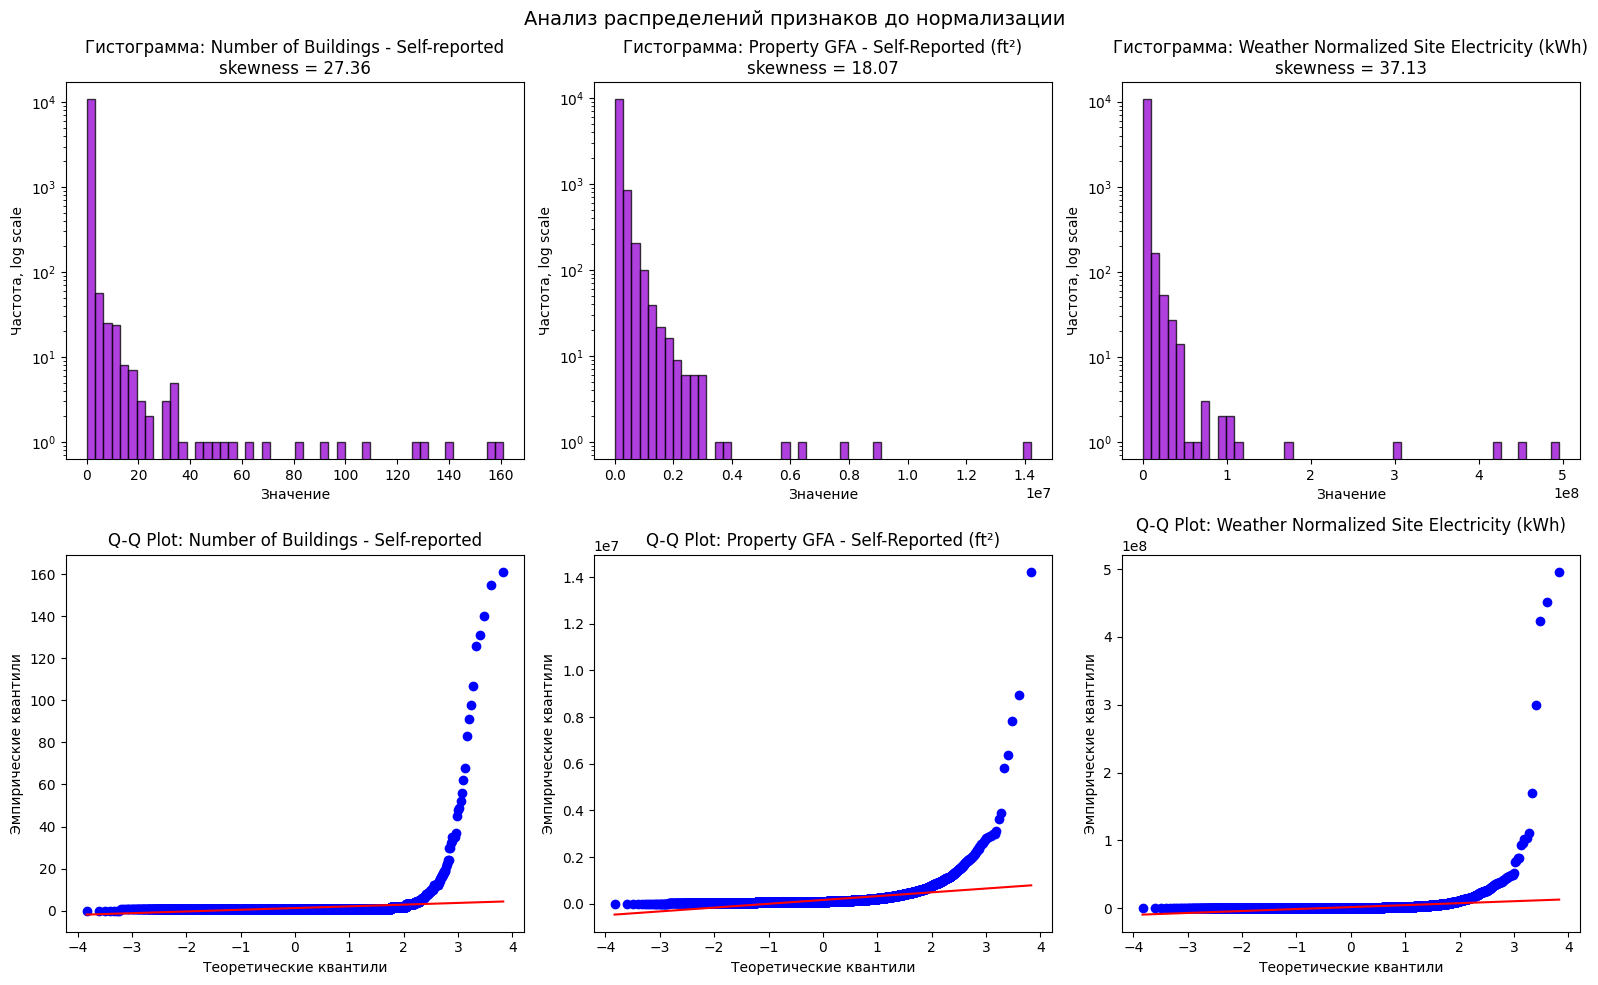

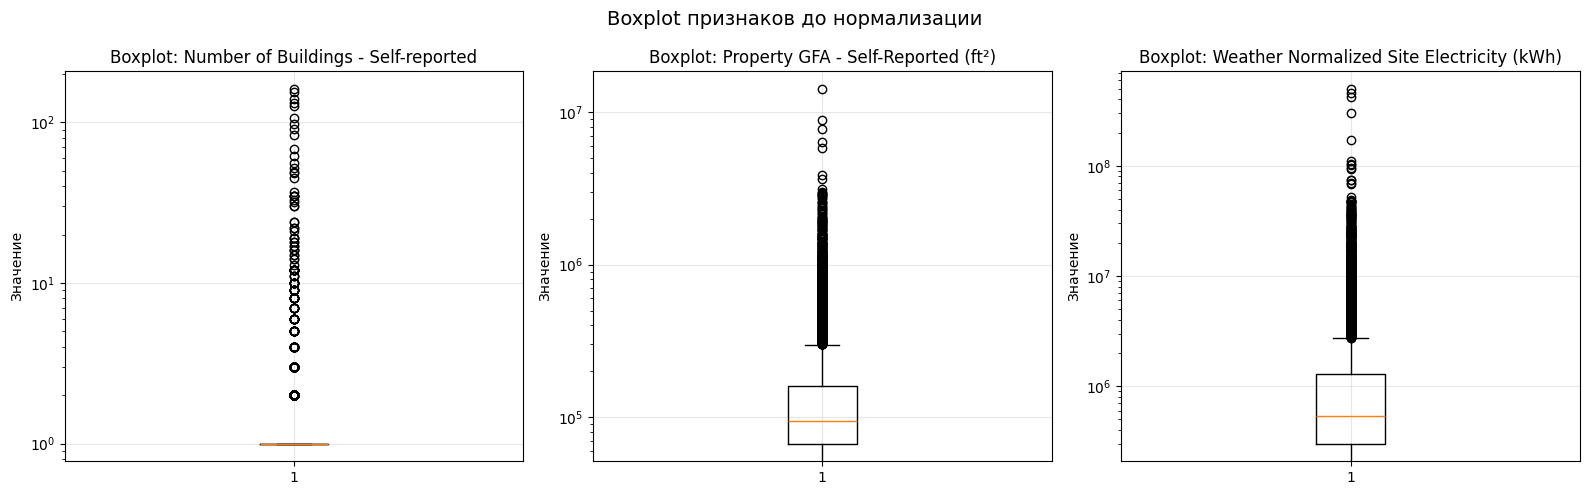


Нормализация признаков средствами sklearn

1. StandardScaler
Дает Z оценку - насколько далеко значение находится от среднего в единицах стандартного отклонения.
   Среднее после нормализации: [ 0. -0.  0.]
   Дисперсия после нормализации: [1. 1. 1.]

2. MinMaxScaler
переводит значения в диапазон от 0 до 1
   Минимум после нормализации: [0. 0. 0.]
   Максимум после нормализации: [1. 1. 1.]

3. RobustScaler
масштабирует относительно медианы и квартилей
   Медиана после нормализации: [0. 0. 0.]


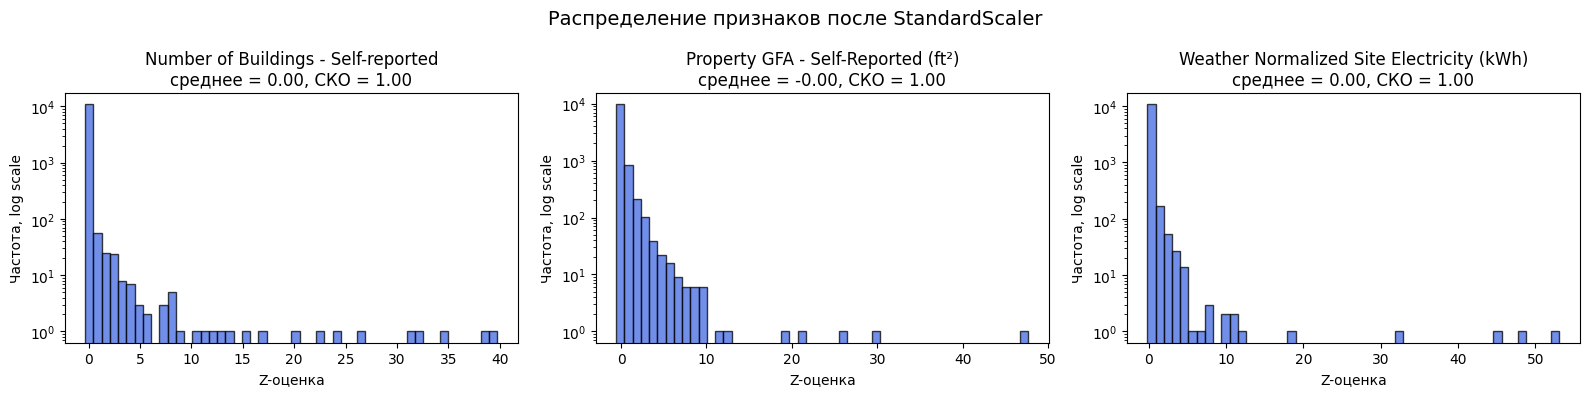

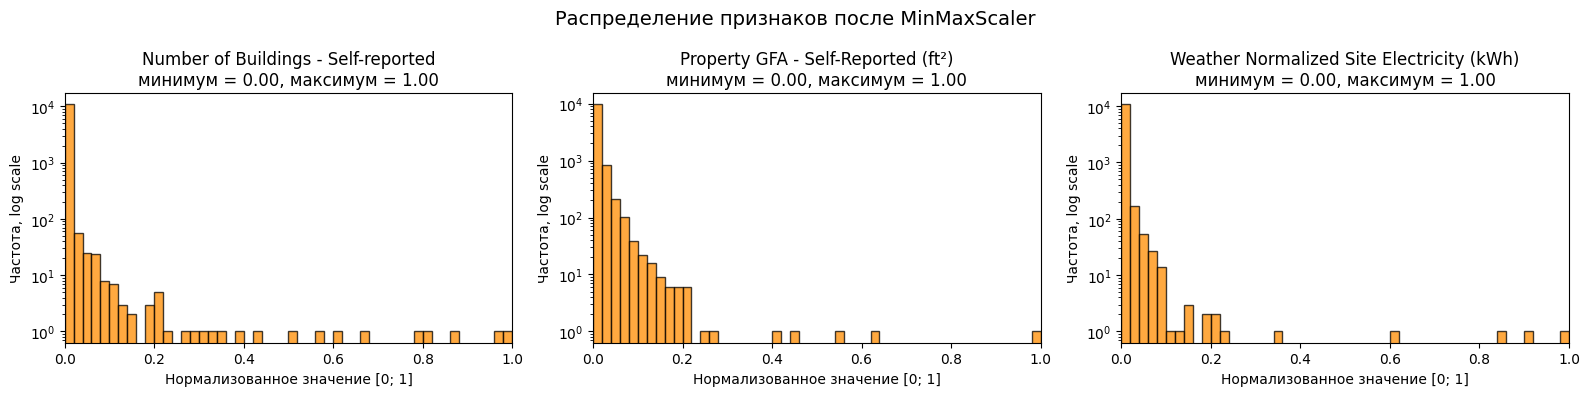

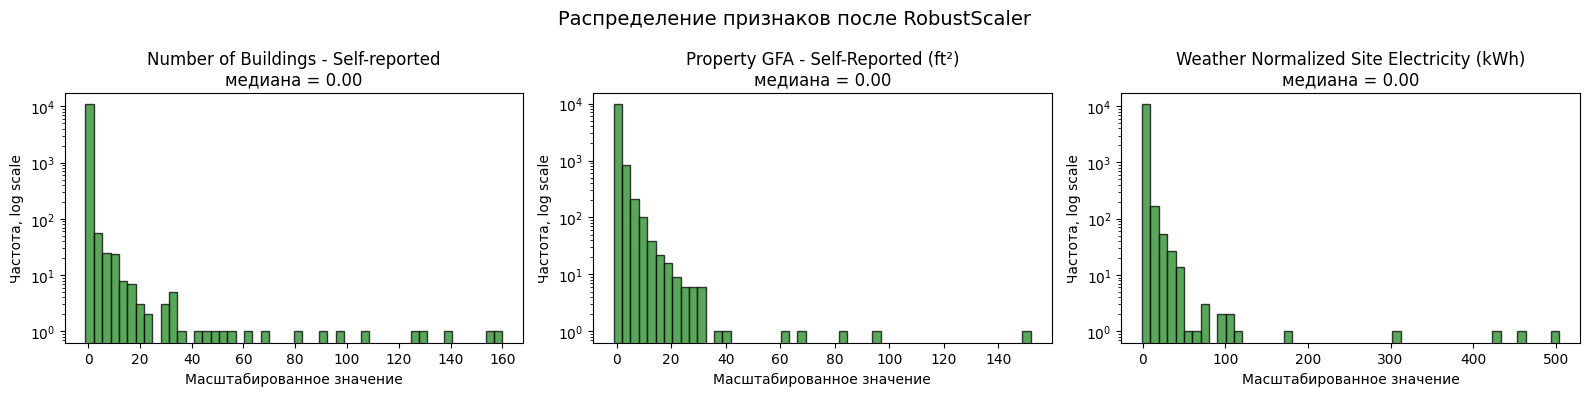

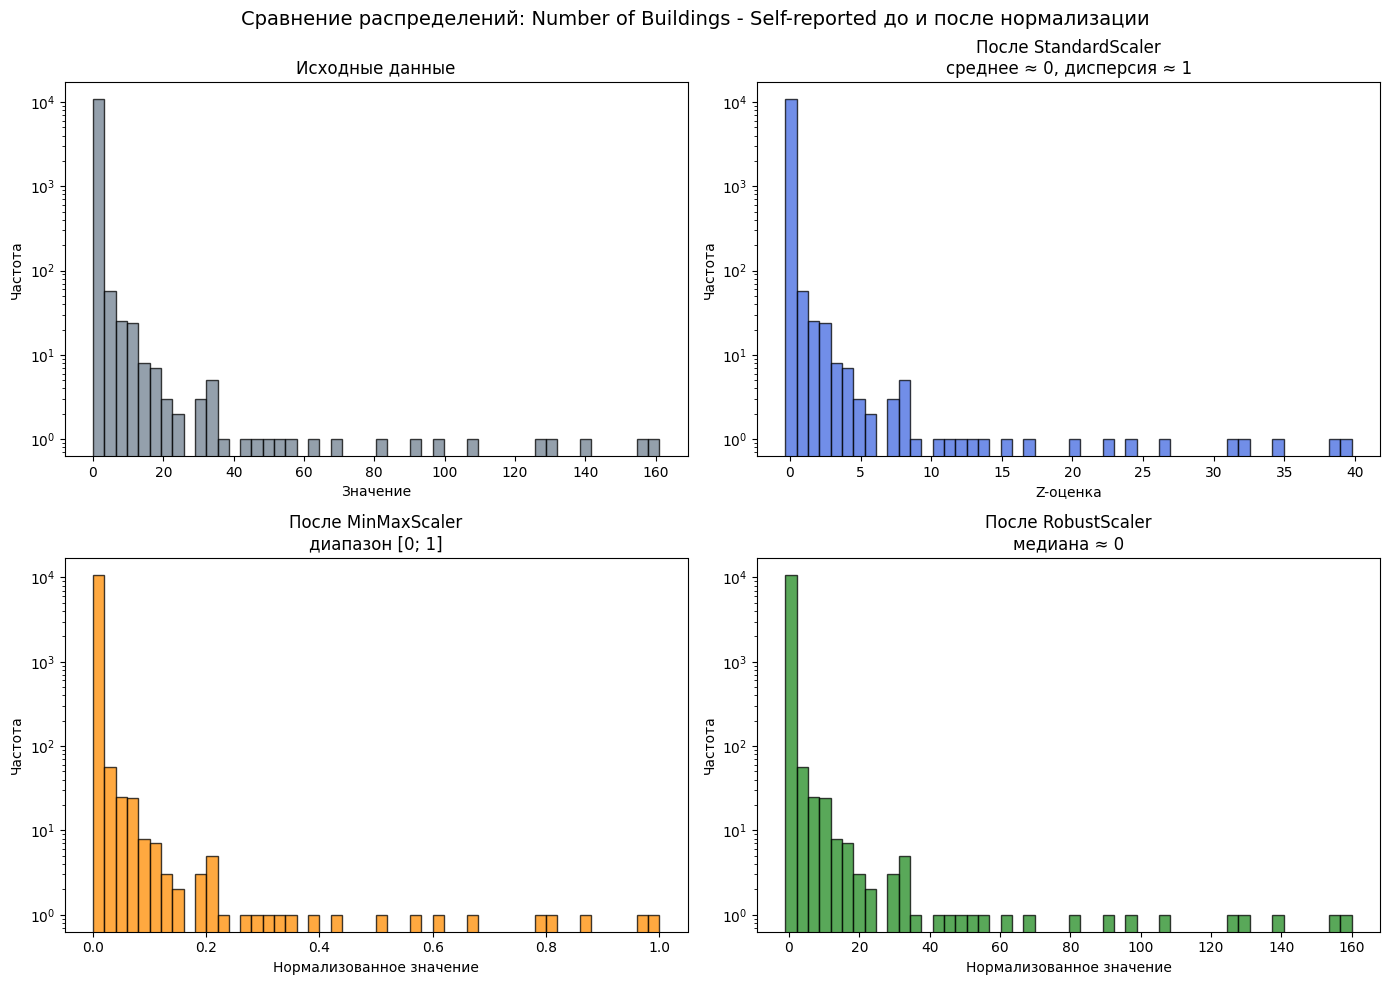

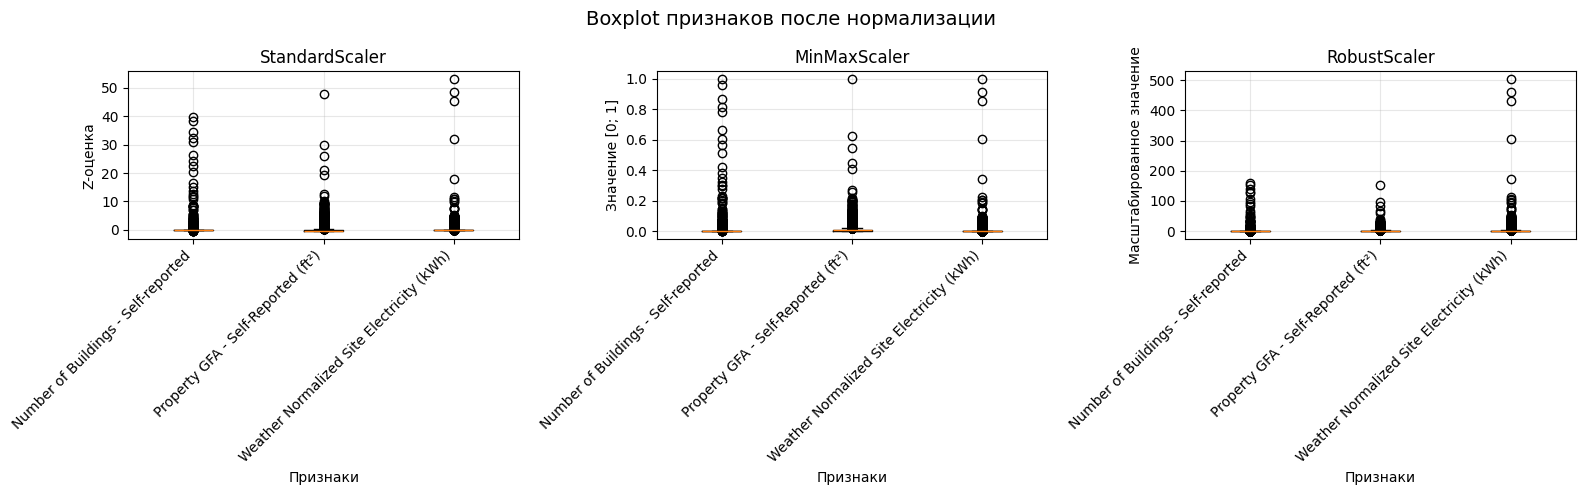


Итоговый вывод:
Были выбраны числовые признаки, связанные с характеристиками здания и энергопотреблением.
Для выбранных признаков были построены гистограммы, Q-Q plot и boxplot.
По значениям коэффициента асимметрии, тесту Шапиро-Уилка и виду графиков видно, что распределения признаков отличаются от нормального.
Это связано с сильной асимметрией, большим разбросом значений и наличием выбросов.
Метод StandardScaler привел признаки к масштабу со средним значением около 0 и дисперсией около 1.
Метод MinMaxScaler привел значения признаков к диапазону [0; 1].
Метод RobustScaler выполнил масштабирование относительно медианы.


In [75]:

# Настройка вывода чисел в pandas: 2 знака после запятой
pd.options.display.float_format = '{:.2f}'.format


# Загружаем датасет
df = pd.read_csv(
    '09_Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017__Data_for_Calendar_Year_2016_.csv',
    low_memory=False
)

df = df.replace('Not Available', np.nan)


# Целевой признак энергопотребления
target = 'Site EUI (kBtu/ft²)'

# Признаки, которые будем анализировать на нормальность и нормализовать
features = [
    'Number of Buildings - Self-reported',
    'Property GFA - Self-Reported (ft²)',
    'Weather Normalized Site Electricity (kWh)'
]


# Приводим выбранные признаки и целевой столбец к числовому типу
# Если в числах есть запятые, например "1,234.5", удаляем их
for col in features + [target]:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '', regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')


# Удаляем строки, где есть пропуски в выбранных признаках или целевой переменной
df_clean = df.dropna(subset=features + [target]).copy()

print(f"Данные загружены: количество строк после очистки = {df_clean.shape[0]}")
print(f"Количество выбранных признаков = {len(features)}")


print("\nАнализ признаков на нормальность")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Анализ распределений признаков до нормализации', fontsize=14)

for idx, col in enumerate(features):
    column_data = df_clean[col].dropna()

    # Коэффициент асимметрии показывает, насколько распределение скошено
    skewness = column_data.skew()

    # Эксцесс показывает выраженность "хвостов" распределения
    kurtosis = column_data.kurtosis()

    # Тест Шапиро-Уилка проверяет гипотезу о нормальности распределения.
    # Для больших выборок берем случайные 5000 значений, чтобы тест работал корректнее и быстрее.
    if len(column_data) > 5000:
        sample_data = column_data.sample(5000, random_state=42)
    else:
        sample_data = column_data

    shapiro_stat, shapiro_p = stats.shapiro(sample_data)

    print(f"\nПризнак: {col}")
    print(f"  Среднее значение: {column_data.mean():.2f}")
    print(f"  Медиана: {column_data.median():.2f}")
    print(f"  Стандартное отклонение: {column_data.std():.2f}")
    print(f"  Коэффициент асимметрии: {skewness:.2f}")
    print(f"  Эксцесс: {kurtosis:.2f}")
    print(f"  Тест Шапиро-Уилка: p-value = {shapiro_p:.6f}")

    if skewness > 1:
        print("  Вывод: сильная правосторонняя асимметрия")
    elif skewness < -1:
        print("  Вывод: сильная левосторонняя асимметрия")
    elif abs(skewness) > 0.5:
        print("  Вывод: умеренная асимметрия")
    else:
        print("  Вывод: распределение близко к симметричному")

    if shapiro_p > 0.05:
        print("  По тесту Шапиро-Уилка распределение можно считать нормальным")
    else:
        print("  По тесту Шапиро-Уилка распределение не является нормальным")

    # Гистограмма показывает форму распределения признака
    axes[0, idx].hist(
        column_data,
        bins=50,
        alpha=0.75,
        color='darkviolet',
        edgecolor='black'
    )
    
    axes[0, idx].set_yscale('log')
    
    axes[0, idx].set_title(f'Гистограмма: {col}\nskewness = {skewness:.2f}')
    axes[0, idx].set_xlabel('Значение')
    axes[0, idx].set_ylabel('Частота, log scale')

    # Q-Q plot показывает, насколько распределение похоже на нормальное.
    # Если точки близки к прямой линии, распределение ближе к нормальному.
    stats.probplot(column_data, dist="norm", plot=axes[1, idx])
    axes[1, idx].set_title(f'Q-Q Plot: {col}')
    axes[1, idx].set_xlabel('Теоретические квантили')
    axes[1, idx].set_ylabel('Эмпирические квантили')

plt.tight_layout()
plt.show()


# Boxplot помогает увидеть выбросы и разброс значений до нормализации
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Boxplot признаков до нормализации', fontsize=14)

for idx, col in enumerate(features):
    axes[idx].boxplot(df_clean[col])
    axes[idx].set_title(f'Boxplot: {col}')
    axes[idx].set_ylabel('Значение')

    # Логарифмическая шкала помогает лучше увидеть распределение,
    # если значения сильно отличаются по масштабу
    axes[idx].set_yscale('log')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\nНормализация признаков средствами sklearn")

# Матрица признаков для нормализации
X = df_clean[features]


# StandardScaler:
# приводит признаки к среднему значению 0 и дисперсии 1
scaler_std = StandardScaler()
X_standardized = scaler_std.fit_transform(X)

print("\n1. StandardScaler")
print("Дает Z оценку - насколько далеко значение находится от среднего в единицах стандартного отклонения.")
print(f"   Среднее после нормализации: {X_standardized.mean(axis=0).round(2)}")
print(f"   Дисперсия после нормализации: {X_standardized.var(axis=0).round(2)}")


# MinMaxScaler:
# приводит значения каждого признака к диапазону [0; 1]
scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

print("\n2. MinMaxScaler")
print("переводит значения в диапазон от 0 до 1")
print(f"   Минимум после нормализации: {X_minmax.min(axis=0).round(2)}")
print(f"   Максимум после нормализации: {X_minmax.max(axis=0).round(2)}")


# RobustScaler:
# масштабирует данные относительно медианы и межквартильного размаха.
# Хорошо подходит, если в данных есть выбросы.
scaler_robust = RobustScaler()
X_robust = scaler_robust.fit_transform(X)

print("\n3. RobustScaler")
print("масштабирует относительно медианы и квартилей")
print(f"   Медиана после нормализации: {np.median(X_robust, axis=0).round(2)}")


# Гистограммы после StandardScaler
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Распределение признаков после StandardScaler', fontsize=14)

for idx, col in enumerate(features):
    axes[idx].hist(
        X_standardized[:, idx],
        bins=50,
        alpha=0.75,
        color='royalblue',
        edgecolor='black'
    )
    
    axes[idx].set_yscale('log')
    
    axes[idx].set_title(
        f'{col}\nсреднее = {X_standardized[:, idx].mean():.2f}, '
        f'СКО = {X_standardized[:, idx].std():.2f}'
    )
    
    axes[idx].set_xlabel('Z-оценка')
    axes[idx].set_ylabel('Частота, log scale')

plt.tight_layout()
plt.show()


# Гистограммы после MinMaxScaler
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Распределение признаков после MinMaxScaler', fontsize=14)

for idx, col in enumerate(features):
    axes[idx].hist(
        X_minmax[:, idx],
        bins=50,
        alpha=0.75,
        color='darkorange',
        edgecolor='black'
    )
    
    axes[idx].set_yscale('log')
    axes[idx].set_xlim(0, 1)
    
    axes[idx].set_title(
        f'{col}\nминимум = {X_minmax[:, idx].min():.2f}, '
        f'максимум = {X_minmax[:, idx].max():.2f}'
    )
    
    axes[idx].set_xlabel('Нормализованное значение [0; 1]')
    axes[idx].set_ylabel('Частота, log scale')

plt.tight_layout()
plt.show()


# Гистограммы после RobustScaler
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Распределение признаков после RobustScaler', fontsize=14)

for idx, col in enumerate(features):
    axes[idx].hist(
        X_robust[:, idx],
        bins=50,
        alpha=0.75,
        color='forestgreen',
        edgecolor='black'
    )
    
    axes[idx].set_yscale('log')
    
    axes[idx].set_title(
        f'{col}\nмедиана = {np.median(X_robust[:, idx]):.2f}'
    )
    
    axes[idx].set_xlabel('Масштабированное значение')
    axes[idx].set_ylabel('Частота, log scale')

plt.tight_layout()
plt.show()


# Сравним распределение первого признака до и после разных способов нормализации
first_feature = features[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Сравнение распределений: {first_feature} до и после нормализации',
    fontsize=14
)

axes[0, 0].hist(
    df_clean[first_feature],
    bins=50,
    alpha=0.75,
    color='slategray',
    edgecolor='black'
)
axes[0, 0].set_title('Исходные данные')
axes[0, 0].set_xlabel('Значение')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].set_yscale('log')


axes[0, 1].hist(
    X_standardized[:, 0],
    bins=50,
    alpha=0.75,
    color='royalblue',
    edgecolor='black'
)
axes[0, 1].set_title('После StandardScaler\nсреднее ≈ 0, дисперсия ≈ 1')
axes[0, 1].set_xlabel('Z-оценка')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].set_yscale('log')

axes[1, 0].hist(
    X_minmax[:, 0],
    bins=50,
    alpha=0.75,
    color='darkorange',
    edgecolor='black'
)
axes[1, 0].set_title('После MinMaxScaler\nдиапазон [0; 1]')
axes[1, 0].set_xlabel('Нормализованное значение')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].set_yscale('log')

axes[1, 1].hist(
    X_robust[:, 0],
    bins=50,
    alpha=0.75,
    color='forestgreen',
    edgecolor='black'
)
axes[1, 1].set_title('После RobustScaler\nмедиана ≈ 0')
axes[1, 1].set_xlabel('Нормализованное значение')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()


# Boxplot после разных способов нормализации
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Boxplot признаков после нормализации', fontsize=14)

axes[0].boxplot(X_standardized)
axes[0].set_title('StandardScaler')
axes[0].set_xlabel('Признаки')
axes[0].set_ylabel('Z-оценка')
axes[0].set_xticklabels(features, rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(X_minmax)
axes[1].set_title('MinMaxScaler')
axes[1].set_xlabel('Признаки')
axes[1].set_ylabel('Значение [0; 1]')
axes[1].set_xticklabels(features, rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)

axes[2].boxplot(X_robust)
axes[2].set_title('RobustScaler')
axes[2].set_xlabel('Признаки')
axes[2].set_ylabel('Масштабированное значение')
axes[2].set_xticklabels(features, rotation=45, ha='right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\nИтоговый вывод:")
print("Были выбраны числовые признаки, связанные с характеристиками здания и энергопотреблением.")
print("Для выбранных признаков были построены гистограммы, Q-Q plot и boxplot.")
print("По значениям коэффициента асимметрии, тесту Шапиро-Уилка и виду графиков видно, что распределения признаков отличаются от нормального.")
print("Это связано с сильной асимметрией, большим разбросом значений и наличием выбросов.")
print("Метод StandardScaler привел признаки к масштабу со средним значением около 0 и дисперсией около 1.")
print("Метод MinMaxScaler привел значения признаков к диапазону [0; 1].")
print("Метод RobustScaler выполнил масштабирование относительно медианы.")

#### Задание 3. Загрузить датасет проанализировать на сбалансированность, применить методы балансировки, воспользоваться встроенными методами библиотеки sklearn, сделать выводы.
**Датасет: 10_fire_dataset_bin.xlsx
данные о лесных пожарах.
Целевая переменная для балансировки - area.**

Размер датасета: (8166, 22)

Уникальные значения area:
[0 1]

Распределение классов до балансировки:
area
0    7744
1     422
Name: count, dtype: int64

Мажоритарный класс: 0
Миноритарный класс: 1

Распределение классов после Oversampling:
area
0    7744
1    7744
Name: count, dtype: int64

Распределение классов после Undersampling:
area
0    422
1    422
Name: count, dtype: int64

Распределение классов после комбинированной балансировки:
area
0    4083
1    4083
Name: count, dtype: int64

Веса классов:
{np.int64(0): np.float64(0.5272469008264463), np.int64(1): np.float64(9.675355450236967)}

Первые 10 весов объектов:
[0.5272469 0.5272469 0.5272469 0.5272469 0.5272469 0.5272469 0.5272469
 0.5272469 0.5272469 0.5272469]

Сравнение распределений классов:


,До балансировки,Oversampling,Undersampling,Комбинированный метод
area,,,,
0,7744,7744,422,4083
1,422,7744,422,4083


Сравнение распределения классов:


,До балансировки,Oversampling,Undersampling,Комбинированный метод
area,,,,
0,7744,7744,422,4083
1,422,7744,422,4083


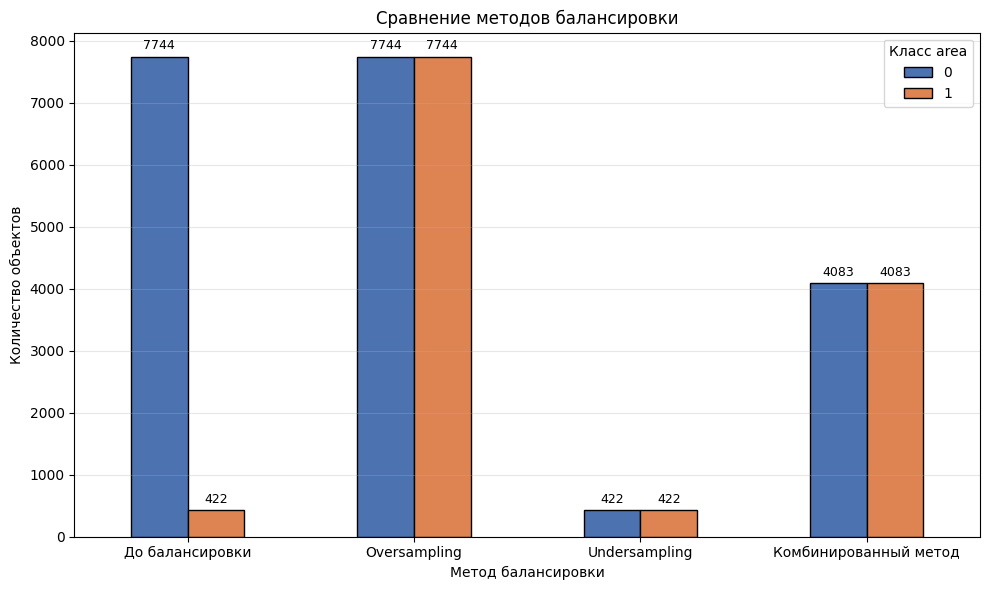

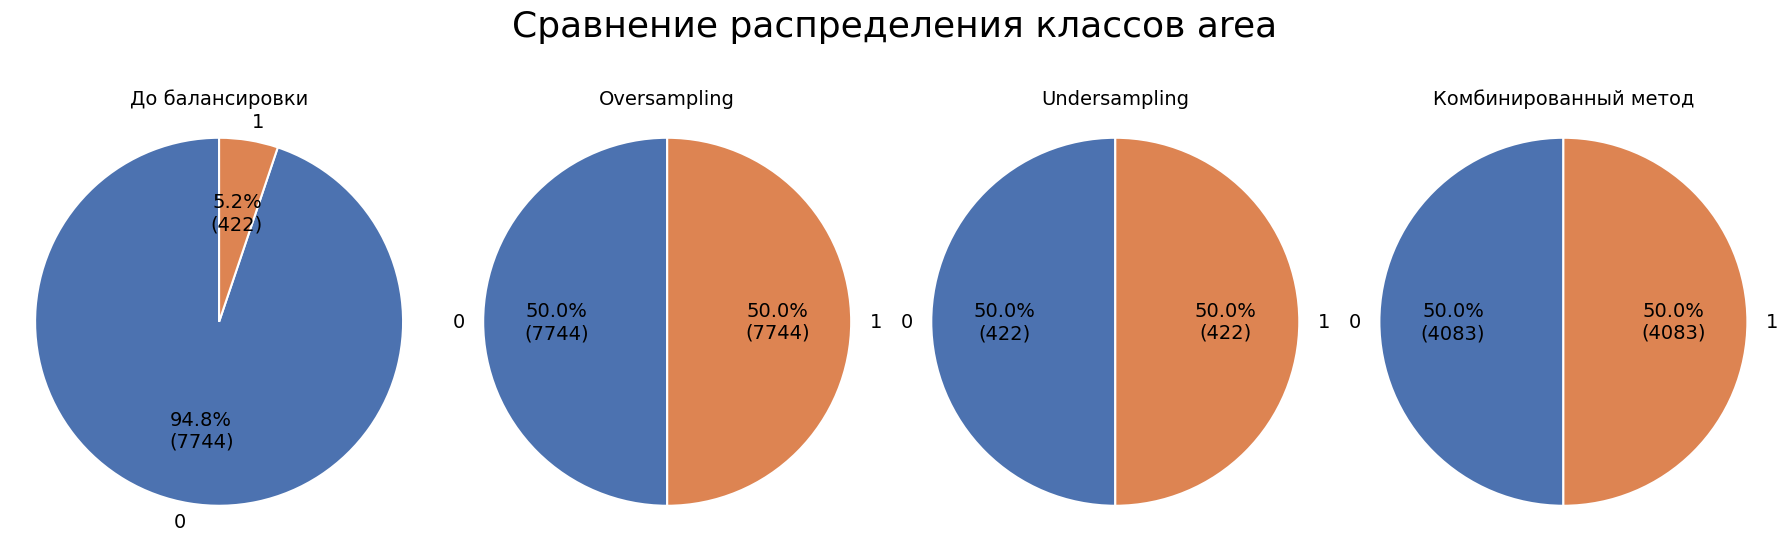


Вывод по сравнению методов:
До балансировки классы распределены неравномерно.
После Oversampling количество объектов миноритарного класса увеличено до размера мажоритарного класса.
После Undersampling количество объектов мажоритарного класса уменьшено до размера миноритарного класса.
Комбинированный метод приводит классы к промежуточному одинаковому размеру.
На круговых диаграммах видно, что после применения методов балансировки доли классов становятся примерно равными.
Oversampling сохраняет все исходные данные, но добавляет повторяющиеся объекты.
Undersampling удаляет часть данных, поэтому может привести к потере информации.
Комбинированный метод является компромиссом между oversampling и undersampling.


In [69]:

data = pd.read_excel('10_fire_dataset_bin.xlsx')

target = 'area'

print('Размер датасета:', data.shape)

# Удаляем строки с пропусками в целевой переменной
data = data.dropna(subset=[target])

print('\nУникальные значения area:')
print(data[target].unique())


def show_pie(class_counts, title):
    plt.figure(figsize=(6, 6))

    plt.pie(
        class_counts.values,
        labels=class_counts.index.astype(str),
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Set3.colors,
        wedgeprops={'edgecolor': 'black'}
    )

    plt.title(title)
    plt.show()


class_counts = data[target].value_counts().sort_index()

print('\nРаспределение классов до балансировки:')
print(class_counts)


majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

data_majority = data[data[target] == majority_class]
data_minority = data[data[target] == minority_class]

print('\nМажоритарный класс:', majority_class)
print('Миноритарный класс:', minority_class)


# Метод 1: Oversampling
# Увеличиваем меньший класс до размера большего
data_minority_oversampled = resample(
    data_minority,
    replace=True,
    n_samples=len(data_majority),
    random_state=42
)

data_oversampled = pd.concat([data_majority, data_minority_oversampled])
data_oversampled = data_oversampled.sample(frac=1, random_state=42).reset_index(drop=True)

oversampled_counts = data_oversampled[target].value_counts().sort_index()

print('\nРаспределение классов после Oversampling:')
print(oversampled_counts)


# Метод 2: Undersampling
# Уменьшаем больший класс до размера меньшего
data_majority_undersampled = resample(
    data_majority,
    replace=False,
    n_samples=len(data_minority),
    random_state=42
)

data_undersampled = pd.concat([data_majority_undersampled, data_minority])
data_undersampled = data_undersampled.sample(frac=1, random_state=42).reset_index(drop=True)

undersampled_counts = data_undersampled[target].value_counts().sort_index()

print('\nРаспределение классов после Undersampling:')
print(undersampled_counts)


# Метод 3: Комбинированная балансировка
# Берем промежуточный размер: среднее между размерами классов.
# Больший класс уменьшаем, меньший класс увеличиваем.
target_size = int((len(data_majority) + len(data_minority)) / 2)

data_majority_combined = resample(
    data_majority,
    replace=False,
    n_samples=target_size,
    random_state=42
)

data_minority_combined = resample(
    data_minority,
    replace=True,
    n_samples=target_size,
    random_state=42
)

data_combined = pd.concat([data_majority_combined, data_minority_combined])
data_combined = data_combined.sample(frac=1, random_state=42).reset_index(drop=True)

combined_counts = data_combined[target].value_counts().sort_index()

print('\nРаспределение классов после комбинированной балансировки:')
print(combined_counts)


# Метод 4: Веса классов
# Этот метод не меняет количество строк в датасете.
# Он задает больший вес редкому классу для дальнейшего обучения модели.
classes = data[target].unique()

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=data[target]
)

class_weights_dict = dict(zip(classes, class_weights))

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=data[target]
)

print('\nВеса классов:')
print(class_weights_dict)

print('\nПервые 10 весов объектов:')
print(sample_weights[:10])


summary = pd.DataFrame({
    'До балансировки': class_counts,
    'Oversampling': oversampled_counts,
    'Undersampling': undersampled_counts,
    'Комбинированный метод': combined_counts
})

print('\nСравнение распределений классов:')
display(summary)

summary = pd.DataFrame({
    'До балансировки': class_counts,
    'Oversampling': oversampled_counts,
    'Undersampling': undersampled_counts,
    'Комбинированный метод': combined_counts
}).fillna(0).astype(int)

print('Сравнение распределения классов:')
display(summary)


# Столбчатая диаграмма сравнения методов
ax = summary.T.plot(
    kind='bar',
    figsize=(10, 6),
    edgecolor='black',
    color=['#4C72B0', '#DD8452']
)

plt.title('Сравнение методов балансировки')
plt.xlabel('Метод балансировки')
plt.ylabel('Количество объектов')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Класс area')

# Подписи значений над каждым столбцом
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%d',
        padding=3,
        fontsize=9
    )

plt.tight_layout()
plt.show()

print("\n")

# Круговые диаграммы для каждого метода
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

pie_data = [
    ('До балансировки', class_counts),
    ('Oversampling', oversampled_counts),
    ('Undersampling', undersampled_counts),
    ('Комбинированный метод', combined_counts)
]

colors = ['#4C72B0', '#DD8452']

def make_autopct(values):
    def autopct(percent):
        total = sum(values)
        count = int(round(percent * total / 100.0))
        return f'{percent:.1f}%\n({count})'
    return autopct

for ax, (title, counts) in zip(axes, pie_data):
    ax.pie(
        counts.values,
        labels=counts.index.astype(str),
        autopct=make_autopct(counts.values),
        startangle=90,
        colors=colors,
        radius=1.1,
        wedgeprops={
            'edgecolor': 'white',
            'linewidth': 1.5
        },
        textprops={
            'fontsize': 14
        }
    )

    ax.set_title(title, fontsize=14)

plt.suptitle('Сравнение распределения классов area', fontsize=26)
plt.tight_layout()
plt.show()


print('\nВывод по сравнению методов:')
print('До балансировки классы распределены неравномерно.')
print('После Oversampling количество объектов миноритарного класса увеличено до размера мажоритарного класса.')
print('После Undersampling количество объектов мажоритарного класса уменьшено до размера миноритарного класса.')
print('Комбинированный метод приводит классы к промежуточному одинаковому размеру.')
print('На круговых диаграммах видно, что после применения методов балансировки доли классов становятся примерно равными.')
print('Oversampling сохраняет все исходные данные, но добавляет повторяющиеся объекты.')
print('Undersampling удаляет часть данных, поэтому может привести к потере информации.')
print('Комбинированный метод является компромиссом между oversampling и undersampling.')

#### Задание 4. Загрузить датасет проанализировать на наличие аномалий и выбросов, сделать визуализацию, сделать выводы.  
**Датасет: 10_fire_dataset_bin.xlsx
данные о лесных пожарах.
Целевая переменная – area**

Датасет загружен
Размер датасета: (8166, 22)


,Unnamed: 0,area,lon,lat,Dist_str,Dist_railw,Dist_car,T,Po,P,...,DD,Ff,N,WW,Cl,Nh,H,Cm,VV,Td
0,2017-09-24 10:00:00,0,0.00,0.00,0.00,0.00,0.00,9.40,761.90,774.80,...,"Ветер, дующий с востока",2,100%.,NaN,"Слоисто-кучевые, образовавшиеся не из кучевых.",50%.,600-1000,"Высококучевые просвечивающие, расположенные на...",10.00,4.30
1,2017-09-24 13:00:00,0,0.00,0.00,0.00,0.00,0.00,11.70,762.40,775.20,...,"Ветер, дующий с северо-северо-востока",3,70 – 80%.,NaN,"Слоисто-кучевые, образовавшиеся не из кучевых.",70 – 80%.,600-1000,"Высококучевых, высокослоистых или слоисто-дожд...",10.00,3.10
2,2017-09-24 16:00:00,0,0.00,0.00,0.00,0.00,0.00,11.60,762.70,775.60,...,"Ветер, дующий с северо-востока",2,70 – 80%.,NaN,"Слоисто-кучевые, образовавшиеся не из кучевых.",70 – 80%.,600-1000,"Высококучевых, высокослоистых или слоисто-дожд...",10.00,2.30
3,2017-09-24 19:00:00,0,0.00,0.00,0.00,0.00,0.00,7.70,763.30,776.40,...,"Ветер, дующий с северо-востока",2,70 – 80%.,NaN,"Кучево-дождевые лысые с кучевыми, слоисто-куче...",70 – 80%.,600-1000,"Высококучевых, высокослоистых или слоисто-дожд...",10.00,1.20
4,2017-09-24 22:00:00,0,0.00,0.00,0.00,0.00,0.00,6.10,763.60,773.70,...,"Ветер, дующий с севера",1,Облаков нет.,NaN,"Кучево-дождевые лысые с кучевыми, слоисто-куче...",70 – 80%.,600-1000,"Высококучевых, высокослоистых или слоисто-дожд...",10.00,2.30



Информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 8166 entries, 0 to 8165
Data columns (total 22 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Unnamed: 0  8166 non-null   datetime64[us]
 1   area        8166 non-null   int64         
 2   lon         8166 non-null   float64       
 3   lat         8166 non-null   float64       
 4   Dist_str    8166 non-null   float64       
 5   Dist_railw  8166 non-null   float64       
 6   Dist_car    8166 non-null   float64       
 7   T           8166 non-null   float64       
 8   Po          8166 non-null   float64       
 9   P           8166 non-null   float64       
 10  Pa          8166 non-null   float64       
 11  U           8166 non-null   int64         
 12  DD          8166 non-null   str           
 13  Ff          8166 non-null   int64         
 14  N           8166 non-null   str           
 15  WW          2335 non-null   str           
 16  Cl         

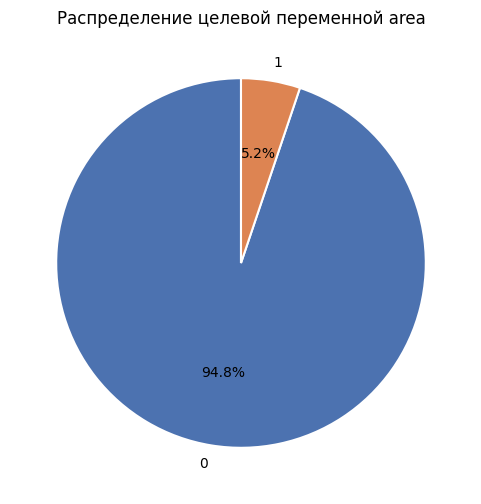


Целевая переменная area является бинарной.
Поэтому выбросы в area как в обычном числовом признаке не анализируются.

Числовые признаки для анализа выбросов:
['lon', 'lat', 'Dist_str', 'Dist_railw', 'Dist_car', 'T', 'Po', 'P', 'Pa', 'U', 'Ff', 'VV', 'Td']

Описательная статистика числовых признаков:


,lon,lat,Dist_str,Dist_railw,Dist_car,T,Po,P,Pa,U,Ff,VV,Td
count,8166.00,8166.00,8166.00,8166.00,8166.00,8166.00,8166.00,8166.00,8166.00,8166.00,8166.00,8166.00,8166.00
mean,2.61,2.75,1902.80,869.27,30.16,5.47,750.73,763.67,0.01,69.34,1.89,9.44,-0.73
std,11.19,11.76,10783.52,4721.99,178.23,11.85,7.53,7.88,0.97,20.82,1.03,2.47,9.15
min,0.00,0.00,0.00,0.00,0.00,-23.80,725.60,738.60,-22.00,12.00,0.00,0.20,-26.20
25%,0.00,0.00,0.00,0.00,0.00,-4.00,745.90,758.50,-0.50,54.00,1.00,10.00,-7.50
50%,0.00,0.00,0.00,0.00,0.00,4.80,750.80,763.60,0.00,74.00,2.00,10.00,-0.80
75%,0.00,0.00,0.00,0.00,0.00,15.00,755.40,768.70,0.50,87.00,3.00,10.00,6.60
max,52.42,54.62,139339.39,53919.35,3065.93,36.10,777.00,790.90,25.20,100.00,7.00,50.00,20.20



Перцентили числовых признаков:


,min,25%,50%,75%,95%,99%,max
lon,0.00,0.00,0.00,0.00,48.63,51.34,52.42
lat,0.00,0.00,0.00,0.00,52.19,53.74,54.62
Dist_str,0.00,0.00,0.00,0.00,718.57,64835.83,139339.39
Dist_railw,0.00,0.00,0.00,0.00,491.21,27579.32,53919.35
Dist_car,0.00,0.00,0.00,0.00,24.47,932.24,3065.93
T,-23.80,-4.00,4.80,15.00,24.90,29.50,36.10
Po,725.60,745.90,750.80,755.40,763.10,770.27,777.00
P,738.60,758.50,763.60,768.70,776.80,784.40,790.90
Pa,-22.00,-0.50,0.00,0.50,1.30,2.30,25.20
U,12.00,54.00,74.00,87.00,97.00,100.00,100.00



Сводка выбросов по числовым признакам:


,min,max,mean,median,std,IQR_outliers_count,IQR_outliers_percent,Z_outliers_count,Z_outliers_percent
lon,0.00,52.42,2.61,0.00,11.19,422.00,5.17,422.00,5.17
lat,0.00,54.62,2.75,0.00,11.76,422.00,5.17,422.00,5.17
Dist_str,0.00,139339.39,1902.80,0.00,10783.52,422.00,5.17,171.00,2.09
Dist_railw,0.00,53919.35,869.27,0.00,4721.99,422.00,5.17,202.00,2.47
Dist_car,0.00,3065.93,30.16,0.00,178.23,422.00,5.17,161.00,1.97
T,-23.80,36.10,5.47,4.80,11.85,0.00,0.00,0.00,0.00
Po,725.60,777.00,750.73,750.80,7.53,185.00,2.27,57.00,0.70
P,738.60,790.90,763.67,763.60,7.88,141.00,1.73,53.00,0.65
Pa,-22.00,25.20,0.01,0.00,0.97,258.00,3.16,64.00,0.78
U,12.00,100.00,69.34,74.00,20.82,0.00,0.00,0.00,0.00


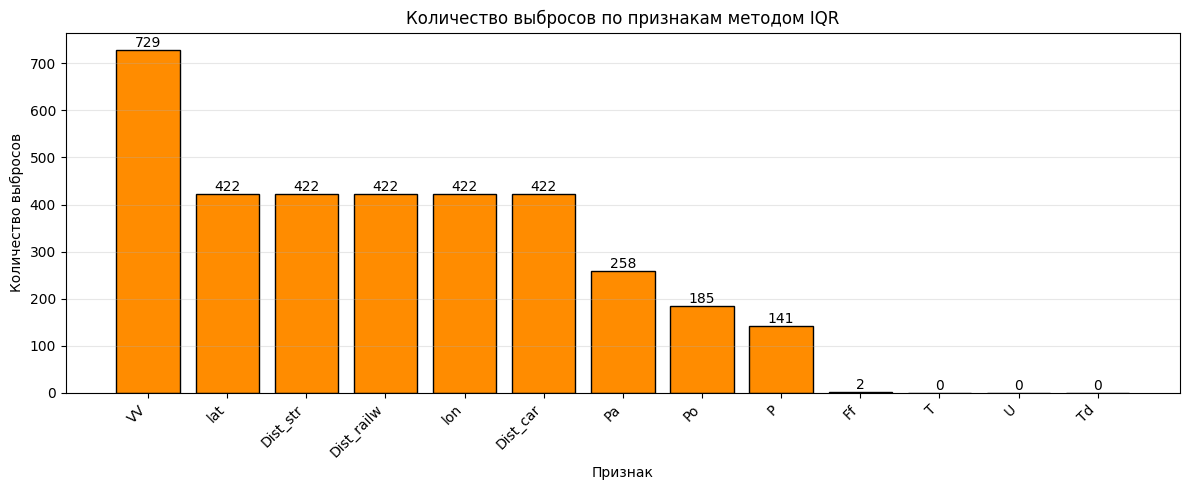

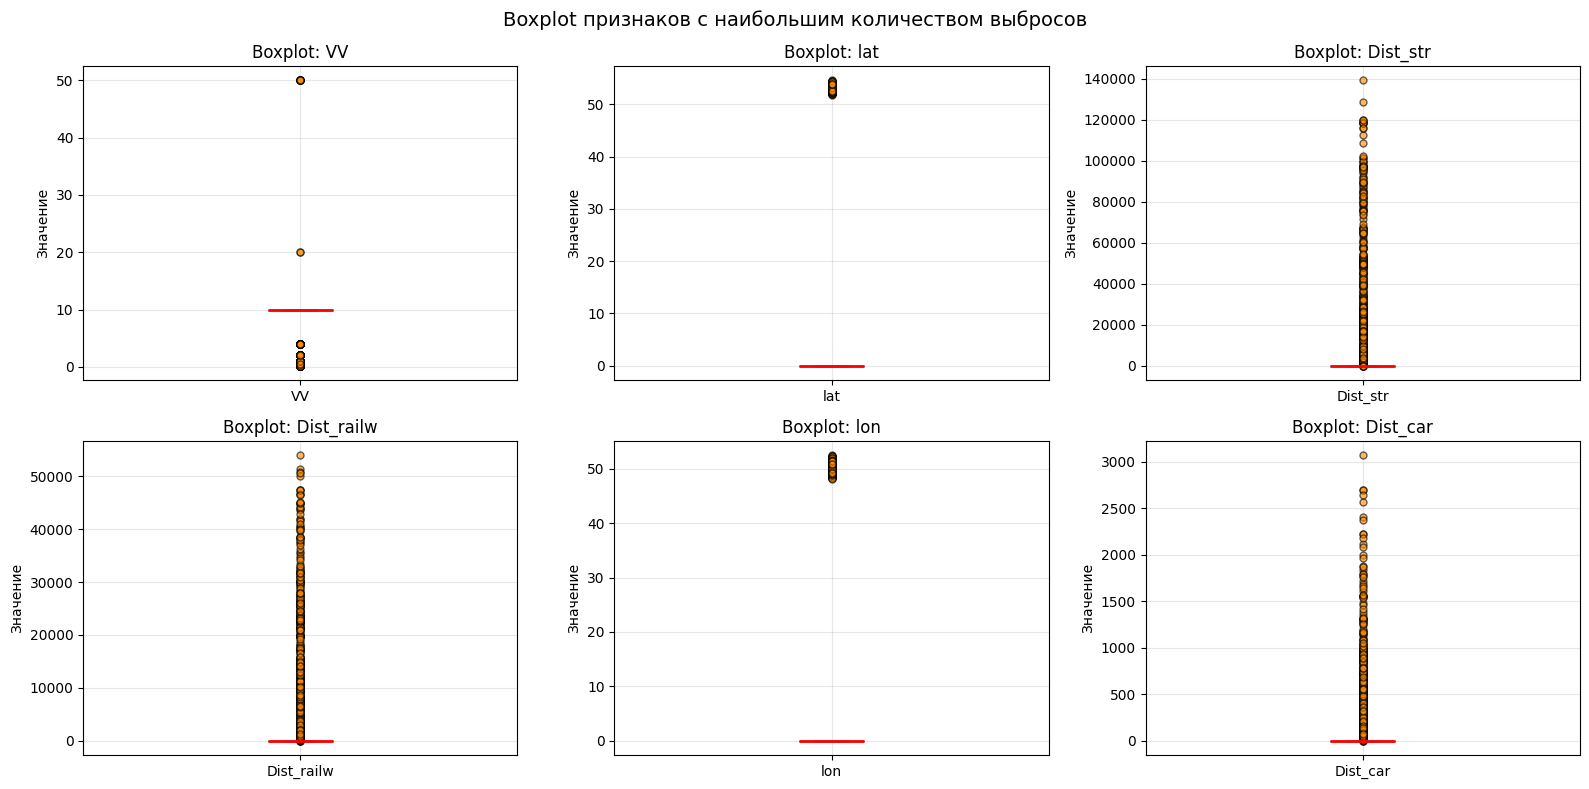


Количество строк с выбросами хотя бы по одному признаку:
IQR_Outlier
False    6715
True     1451
Name: count, dtype: int64


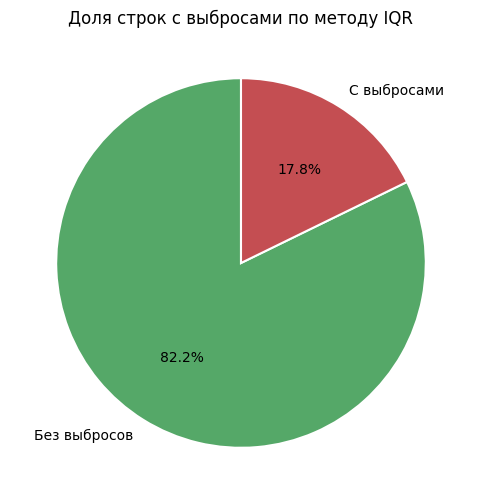


Корреляционная матрица:


,lon,lat,Dist_str,Dist_railw,Dist_car,T,Po,P,Pa,U,Ff,VV,Td,area
lon,1.00,1.00,0.76,0.79,0.73,0.05,0.03,0.03,0.07,-0.15,-0.05,0.04,-0.02,1.00
lat,1.00,1.00,0.75,0.79,0.73,0.05,0.03,0.03,0.07,-0.15,-0.05,0.04,-0.02,1.00
Dist_str,0.76,0.75,1.00,0.79,0.57,0.04,0.02,0.02,0.05,-0.11,-0.04,0.02,-0.00,0.76
Dist_railw,0.79,0.79,0.79,1.00,0.58,0.04,0.03,0.02,0.05,-0.12,-0.04,0.03,-0.01,0.79
Dist_car,0.73,0.73,0.57,0.58,1.00,0.04,0.01,0.01,0.05,-0.12,-0.04,0.04,-0.01,0.72
T,0.05,0.05,0.04,0.04,0.04,1.00,-0.35,-0.41,-0.06,-0.62,-0.03,0.17,0.89,0.05
Po,0.03,0.03,0.02,0.03,0.01,-0.35,1.00,1.00,0.08,0.00,-0.20,0.07,-0.42,0.03
P,0.03,0.03,0.02,0.02,0.01,-0.41,1.00,1.00,0.06,0.04,-0.19,0.05,-0.48,0.03
Pa,0.07,0.07,0.05,0.05,0.05,-0.06,0.08,0.06,1.00,0.06,-0.09,0.11,-0.02,0.07
U,-0.15,-0.15,-0.11,-0.12,-0.12,-0.62,0.00,0.04,0.06,1.00,-0.06,-0.30,-0.21,-0.15


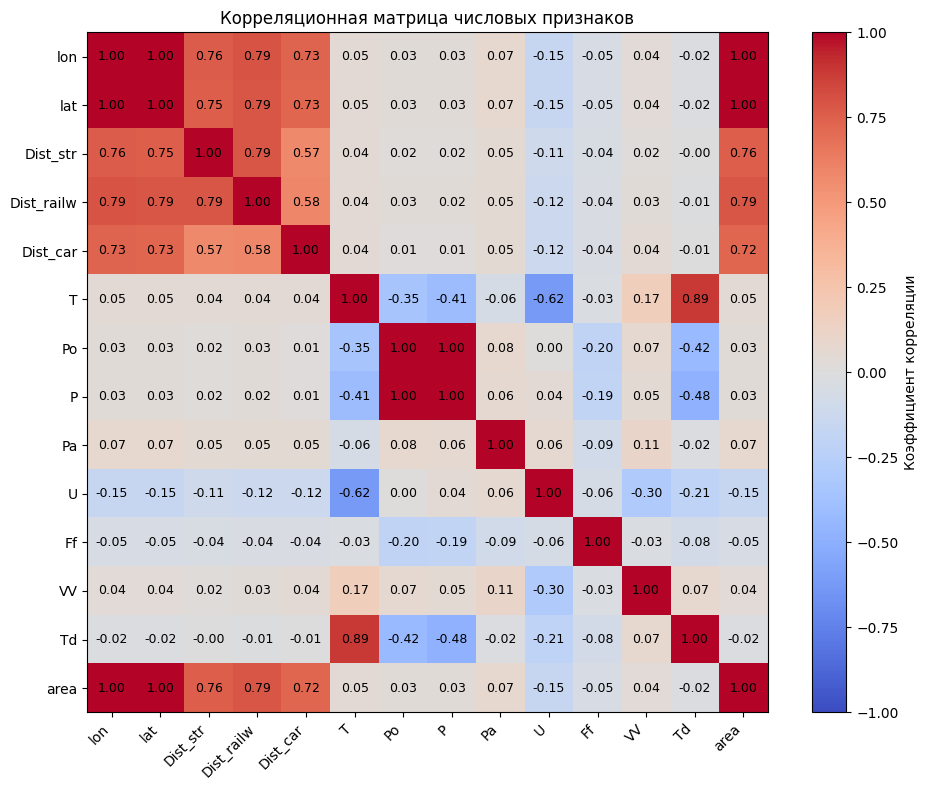


Корреляция признаков с целевой переменной area:


lat           1.00
lon           1.00
Dist_railw    0.79
Dist_str      0.76
Dist_car      0.72
Pa            0.07
T             0.05
VV            0.04
Po            0.03
P             0.03
Td           -0.02
Ff           -0.05
U            -0.15
Name: area, dtype: float64

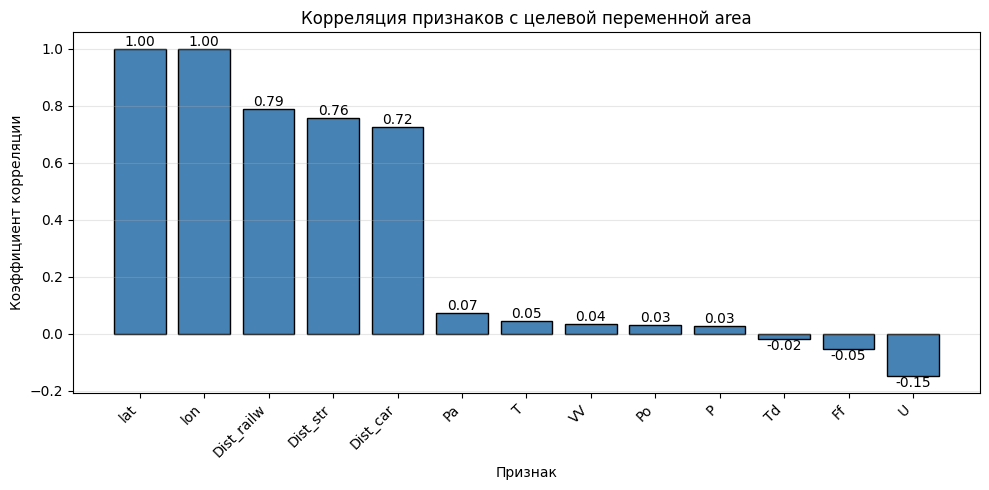


Результат поиска аномалий методом IsolationForest:
anomaly
Норма       7757
Аномалия     409
Name: count, dtype: int64


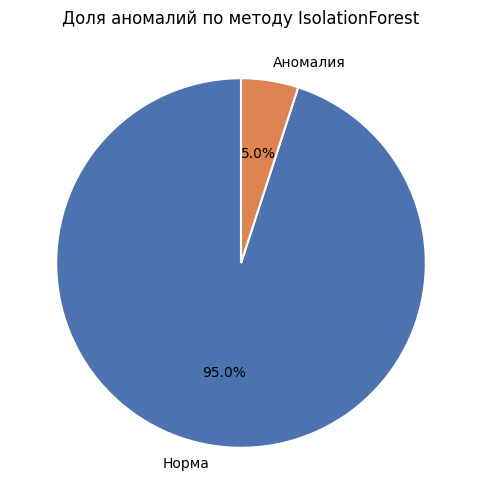

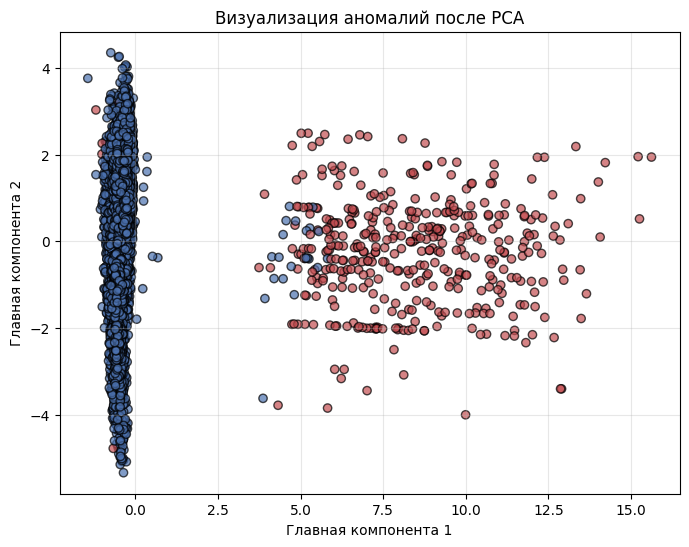


Выводы:
Был выполнен анализ датасета лесных пожаров на наличие выбросов и аномалий.
Выбросы — это отдельные значения признаков, которые сильно отличаются от основной массы данных.
Аномалии — это строки датасета, которые являются нетипичными по совокупности нескольких признаков.
Для поиска выбросов использовались метод IQR и метод Z-score.
Таблица перцентилей показала, насколько крайние значения отличаются от основной массы данных.
Boxplot-графики показали наличие экстремальных значений в отдельных признаках.
Столбчатая диаграмма позволила сравнить количество выбросов по разным признакам.
Корреляционная матрица была построена для анализа взаимосвязей между числовыми признаками.
Корреляция с area показала, какие признаки сильнее связаны с целевой переменной.
Метод IsolationForest был использован для поиска аномальных объектов по совокупности признаков.
PCA-график использовался для визуализации аномалий в двумерном пространстве.
Метод IQR анализирует признаки по отдельности, а IsolationF

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


pd.options.display.float_format = '{:.2f}'.format

data = pd.read_excel('10_fire_dataset_bin.xlsx')

target = 'area'

print('Датасет загружен')
print('Размер датасета:', data.shape)

display(data.head())

print('\nИнформация о датасете:')
data.info()

print('\nКоличество пропусков:')
print(data.isnull().sum())


# Удаляем строки, где отсутствует целевая переменная
data = data.dropna(subset=[target]).copy()


# Анализ целевой переменной area
print('\nРаспределение целевой переменной area:')
area_counts = data[target].value_counts().sort_index()
print(area_counts)

plt.figure(figsize=(6, 6))

plt.pie(
    area_counts.values,
    labels=area_counts.index.astype(str),
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Распределение целевой переменной area')
plt.show()


if data[target].nunique() <= 2:
    print('\nЦелевая переменная area является бинарной.')
    print('Поэтому выбросы в area как в обычном числовом признаке не анализируются.')
else:
    area_data = data[target].dropna()

    q1 = area_data.quantile(0.25)
    q3 = area_data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    area_outliers = area_data[
        (area_data < lower_bound) | (area_data > upper_bound)
    ]

    print('\nАнализ выбросов целевой переменной area методом IQR:')
    print(f'Q1: {q1:.2f}')
    print(f'Q3: {q3:.2f}')
    print(f'IQR: {iqr:.2f}')
    print(f'Нижняя граница: {lower_bound:.2f}')
    print(f'Верхняя граница: {upper_bound:.2f}')
    print(f'Количество выбросов area: {len(area_outliers)}')

    plt.figure(figsize=(6, 5))
    plt.boxplot(
        area_data,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='navy'),
        whiskerprops=dict(color='navy'),
        capprops=dict(color='navy'),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(
            marker='o',
            markerfacecolor='darkorange',
            markeredgecolor='black',
            markersize=5,
            alpha=0.6
        )
    )

    plt.title('Boxplot целевой переменной area')
    plt.ylabel('area')
    plt.grid(True, alpha=0.3)
    plt.show()


# Выбираем числовые признаки
numeric_cols = data.select_dtypes(include='number').columns.tolist()

# Для анализа выбросов берем числовые признаки, кроме целевой переменной
feature_cols = [col for col in numeric_cols if col != target]

print('\nЧисловые признаки для анализа выбросов:')
print(feature_cols)


print('\nОписательная статистика числовых признаков:')
display(data[feature_cols].describe().round(2))


# Таблица перцентилей
percentile_summary = {}

for col in feature_cols:
    col_data = data[col].dropna()

    if len(col_data) == 0:
        continue

    percentile_summary[col] = {
        'min': col_data.min(),
        '25%': col_data.quantile(0.25),
        '50%': col_data.quantile(0.50),
        '75%': col_data.quantile(0.75),
        '95%': col_data.quantile(0.95),
        '99%': col_data.quantile(0.99),
        'max': col_data.max()
    }

percentile_df = pd.DataFrame(percentile_summary).T

print('\nПерцентили числовых признаков:')
display(percentile_df.round(2))


# Поиск выбросов методом IQR и Z-score
outliers_summary = {}

for col in feature_cols:
    col_data = data[col].dropna()

    if len(col_data) == 0 or col_data.nunique() <= 1:
        continue

    q1 = col_data.quantile(0.25)
    q3 = col_data.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers_iqr = col_data[
        (col_data < lower_bound) | (col_data > upper_bound)
    ]

    z_scores = np.abs(stats.zscore(col_data))
    outliers_z = col_data[z_scores > 3]

    outliers_summary[col] = {
        'min': col_data.min(),
        'max': col_data.max(),
        'mean': col_data.mean(),
        'median': col_data.median(),
        'std': col_data.std(),
        'IQR_outliers_count': len(outliers_iqr),
        'IQR_outliers_percent': len(outliers_iqr) / len(col_data) * 100,
        'Z_outliers_count': len(outliers_z),
        'Z_outliers_percent': len(outliers_z) / len(col_data) * 100
    }

outliers_df = pd.DataFrame(outliers_summary).T

print('\nСводка выбросов по числовым признакам:')
display(outliers_df.round(2))


# Столбчатая диаграмма количества выбросов по IQR
iqr_counts = outliers_df['IQR_outliers_count'].sort_values(ascending=False)

plt.figure(figsize=(12, 5))

bars = plt.bar(
    iqr_counts.index,
    iqr_counts.values,
    color='darkorange',
    edgecolor='black'
)

plt.title('Количество выбросов по признакам методом IQR')
plt.xlabel('Признак')
plt.ylabel('Количество выбросов')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


# Boxplot признаков с наибольшим количеством выбросов
selected_cols = iqr_counts.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(selected_cols):
    col_data = data[col].dropna()

    axes[i].boxplot(
        col_data,
        patch_artist=True,
        boxprops=dict(facecolor='lightblue', color='navy'),
        whiskerprops=dict(color='navy'),
        capprops=dict(color='navy'),
        medianprops=dict(color='red', linewidth=2),
        flierprops=dict(
            marker='o',
            markerfacecolor='darkorange',
            markeredgecolor='black',
            markersize=5,
            alpha=0.6
        )
    )

    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel('Значение')
    axes[i].set_xticklabels([col])
    axes[i].grid(True, alpha=0.3)

for j in range(len(selected_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Boxplot признаков с наибольшим количеством выбросов', fontsize=14)
plt.tight_layout()
plt.show()


# Определяем строки, где есть выброс хотя бы по одному признаку
data_iqr = data.copy()
data_iqr['IQR_Outlier'] = False

for col in feature_cols:
    col_data = data_iqr[col].dropna()

    if len(col_data) == 0 or col_data.nunique() <= 1:
        continue

    q1 = data_iqr[col].quantile(0.25)
    q3 = data_iqr[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    data_iqr['IQR_Outlier'] = data_iqr['IQR_Outlier'] | (
        (data_iqr[col] < lower_bound) | (data_iqr[col] > upper_bound)
    )

iqr_outlier_counts = data_iqr['IQR_Outlier'].value_counts()

print('\nКоличество строк с выбросами хотя бы по одному признаку:')
print(iqr_outlier_counts)


plt.figure(figsize=(6, 6))

plt.pie(
    iqr_outlier_counts.values,
    labels=['Без выбросов', 'С выбросами'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#55A868', '#C44E52'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Доля строк с выбросами по методу IQR')
plt.show()


# Корреляционная матрица
corr_data = data[feature_cols + [target]].copy()
corr_matrix = corr_data.corr()

print('\nКорреляционная матрица:')
display(corr_matrix.round(2))

plt.figure(figsize=(10, 8))

plt.imshow(
    corr_matrix,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

plt.colorbar(label='Коэффициент корреляции')

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(corr_matrix.index)),
    corr_matrix.index
)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        plt.text(
            j,
            i,
            f'{corr_matrix.iloc[i, j]:.2f}',
            ha='center',
            va='center',
            fontsize=9
        )

plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()


# Корреляция признаков с целевой переменной area
corr_with_area = corr_matrix[target].drop(target).sort_values(ascending=False)

print('\nКорреляция признаков с целевой переменной area:')
display(corr_with_area.round(2))

plt.figure(figsize=(10, 5))

bars = plt.bar(
    corr_with_area.index,
    corr_with_area.values,
    color='steelblue',
    edgecolor='black'
)

plt.title('Корреляция признаков с целевой переменной area')
plt.xlabel('Признак')
plt.ylabel('Коэффициент корреляции')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom' if height >= 0 else 'top'
    )

plt.tight_layout()
plt.show()


# Поиск аномалий методом IsolationForest
X = data[feature_cols].copy()

# Заполняем возможные пропуски медианой
X = X.fillna(X.median())

# Масштабируем признаки
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# contamination=0.05 означает, что ожидаем примерно 5% аномалий
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

data['anomaly'] = model.fit_predict(X_scaled)

# В sklearn: 1 — нормальный объект, -1 — аномалия
data['anomaly'] = data['anomaly'].map({
    1: 'Норма',
    -1: 'Аномалия'
})

anomaly_counts = data['anomaly'].value_counts()

print('\nРезультат поиска аномалий методом IsolationForest:')
print(anomaly_counts)


plt.figure(figsize=(6, 6))

plt.pie(
    anomaly_counts.values,
    labels=anomaly_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0', '#DD8452'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Доля аномалий по методу IsolationForest')
plt.show()


# PCA-график аномалий
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'anomaly': data['anomaly']
})

colors = pca_df['anomaly'].map({
    'Норма': '#4C72B0',
    'Аномалия': '#C44E52'
})

plt.figure(figsize=(8, 6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=colors,
    alpha=0.7,
    edgecolors='black'
)

plt.title('Визуализация аномалий после PCA')
plt.xlabel('Главная компонента 1')
plt.ylabel('Главная компонента 2')
plt.grid(True, alpha=0.3)

plt.show()


print('\nВыводы:')
print('Был выполнен анализ датасета лесных пожаров на наличие выбросов и аномалий.')
print('Выбросы — это отдельные значения признаков, которые сильно отличаются от основной массы данных.')
print('Аномалии — это строки датасета, которые являются нетипичными по совокупности нескольких признаков.')
print('Для поиска выбросов использовались метод IQR и метод Z-score.')
print('Таблица перцентилей показала, насколько крайние значения отличаются от основной массы данных.')
print('Boxplot-графики показали наличие экстремальных значений в отдельных признаках.')
print('Столбчатая диаграмма позволила сравнить количество выбросов по разным признакам.')
print('Корреляционная матрица была построена для анализа взаимосвязей между числовыми признаками.')
print('Корреляция с area показала, какие признаки сильнее связаны с целевой переменной.')
print('Метод IsolationForest был использован для поиска аномальных объектов по совокупности признаков.')
print('PCA-график использовался для визуализации аномалий в двумерном пространстве.')
print('Метод IQR анализирует признаки по отдельности, а IsolationForest оценивает объект целиком.')
print('Целевая переменная area была рассмотрена отдельно. Если она бинарная, то она является классом, а не обычным числовым признаком для поиска выбросов.')

#### Задание 5. Выполнить парсинг двух страниц с сайта https://zakupki.gov.ru/ (либо другой сайт)  по каждой закупке спарсить номер закупки, дату размещения, обновления и окончание подачи заявок, начальную цену контракта. Данные сохранить в pandas датафрейм и в формат csv.

In [104]:
import requests

from bs4 import BeautifulSoup
from datetime import datetime, timedelta


def parse_laptops_page(page_num):
    url = f'https://webscraper.io/test-sites/e-commerce/static/computers/laptops?page={page_num}'
    
    response = requests.get(url)
    response.raise_for_status()
    
    soup = BeautifulSoup(response.text, 'html.parser')
    
    laptops = []
    
    for laptop in soup.find_all('div', class_='card thumbnail'):
        title_tag = laptop.find('a', class_='title')
        price_tag = laptop.find('h4', class_='price')
        description_tag = laptop.find('p', class_='description')
        reviews_tag = laptop.find('p', class_='review-count')
        
        title = title_tag.text.strip() if title_tag else 'Нет названия'
        price = price_tag.text.strip() if price_tag else 'Нет цены'
        description = description_tag.text.strip() if description_tag else 'Нет описания'
        reviews = reviews_tag.text.strip() if reviews_tag else 'Нет отзывов'
        
        publish_date = datetime(2024, 3, 1) + timedelta(days=page_num)
        update_date = publish_date + timedelta(days=5)
        submission_deadline = publish_date + timedelta(days=15)
        
        purchase = {
            'purchase_number': f'LAPTOP-{page_num}-{len(laptops) + 1}',
            'product_name': title,
            'contract_price': price,
            'description': description,
            'reviews': reviews,
            'publish_date': publish_date.strftime('%Y-%m-%d'),
            'update_date': update_date.strftime('%Y-%m-%d'),
            'submission_deadline': submission_deadline.strftime('%Y-%m-%d')
        }
        
        laptops.append(purchase)
    
    return laptops


all_data = []

for page in [1, 2, 3]:
    print(f'\nПарсинг страницы {page}')
    
    page_data = parse_laptops_page(page)
    all_data.extend(page_data)
    
    print(f'  Найдено записей: {len(page_data)}')


df = pd.DataFrame(all_data)

df.columns = [
    'Номер закупки',
    'Наименование товара',
    'Начальная цена контракта',
    'Описание',
    'Количество отзывов',
    'Дата размещения',
    'Дата обновления',
    'Окончание подачи заявок'
]

print(f'\nВсего собрано: {len(df)} записей')
display(df.head())

df.to_csv(
    'parsed_laptop_purchases.csv',
    index=False,
    encoding='utf-8-sig'
)

print('\nФайл parsed_laptop_purchases.csv сохранен')

print('\nСтатистика')
print(f'Всего: {len(df)}')
print(f'Уникальных товаров: {df["Наименование товара"].nunique()}')
print(f'Диапазон цен: от {df["Начальная цена контракта"].min()} до {df["Начальная цена контракта"].max()}')

print('\nРаспределение по количеству отзывов:')
print(df['Количество отзывов'].value_counts())


Парсинг страницы 1
  Найдено записей: 6

Парсинг страницы 2
  Найдено записей: 6

Парсинг страницы 3
  Найдено записей: 6

Всего собрано: 18 записей


,Номер закупки,Наименование товара,Начальная цена контракта,Описание,Количество отзывов,Дата размещения,Дата обновления,Окончание подачи заявок
0,LAPTOP-1-1,Packard 255 G2,$416.99,"15.6"", AMD E2-3800 1.3GHz, 4GB, 500GB, Windows...",2 reviews,2024-03-02,2024-03-07,2024-03-17
1,LAPTOP-1-2,Aspire E1-510,$306.99,"15.6"", Pentium N3520 2.16GHz, 4GB, 500GB, Linux",2 reviews,2024-03-02,2024-03-07,2024-03-17
2,LAPTOP-1-3,ThinkPad T540p,$1178.99,"15.6"", Core i5-4200M, 4GB, 500GB, Win7 Pro 64bit",2 reviews,2024-03-02,2024-03-07,2024-03-17
3,LAPTOP-1-4,ProBook,$739.99,"14"", Core i5 2.6GHz, 4GB, 500GB, Win7 Pro 64bit",8 reviews,2024-03-02,2024-03-07,2024-03-17
4,LAPTOP-1-5,ThinkPad X240,$1311.99,"12.5"", Core i5-4300U, 8GB, 240GB SSD, Win7 Pro...",12 reviews,2024-03-02,2024-03-07,2024-03-17



Файл parsed_laptop_purchases.csv сохранен

Статистика
Всего: 18
Уникальных товаров: 17
Диапазон цен: от $1033.99 до $745.99

Распределение по количеству отзывов:
Количество отзывов
2 reviews     5
4 reviews     3
12 reviews    2
13 reviews    2
10 reviews    2
8 reviews     1
14 reviews    1
0 reviews     1
9 reviews     1
Name: count, dtype: int64


#### Задание 6. Загрузить и собрать датасет, определить категориальные признаки, применить методы LabelEncoder, One Hot Encoding, написать выводы.
**Датасет: 11_automobiles.rar
Описывает классические автомобили**

In [102]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

columns = [
    'symboling',
    'normalized-losses',
    'make',
    'fuel-type',
    'aspiration',
    'num-of-doors',
    'body-style',
    'drive-wheels',
    'engine-location',
    'wheel-base',
    'length',
    'width',
    'height',
    'curb-weight',
    'engine-type',
    'num-of-cylinders',
    'engine-size',
    'fuel-system',
    'bore',
    'stroke',
    'compression-ratio',
    'horsepower',
    'peak-rpm',
    'city-mpg',
    'highway-mpg',
    'price'
]

data = pd.read_csv(
    './11_automobiles/imports-85.data',
    names=columns,
    na_values='?'
)

print('Датасет загружен')
print(f'Количество строк: {data.shape[0]}')
print(f'Количество столбцов: {data.shape[1]}')

numeric_cols_to_convert = [
    'normalized-losses',
    'bore',
    'stroke',
    'horsepower',
    'peak-rpm',
    'price'
]

for col in numeric_cols_to_convert:
    data[col] = pd.to_numeric(data[col], errors='coerce')


numeric_cols = data.select_dtypes(include='number').columns.tolist()

categorical_cols = [
    col for col in data.columns
    if pd.api.types.is_object_dtype(data[col]) or pd.api.types.is_string_dtype(data[col])
]

print('\nЧисловые признаки:')
for col in numeric_cols:
    print(f'- {col}')

print('\nКатегориальные признаки:')
for col in categorical_cols:
    print(f'- {col}')


print('\nКоличество уникальных значений в категориальных признаках:')
for col in categorical_cols:
    print(f'{col}: {data[col].nunique()} уникальных значений')


print('\nПримеры значений категориальных признаков до кодирования:')
for col in categorical_cols:
    unique_values = data[col].dropna().unique()[:10]
    print(f'{col}: {list(unique_values)}')


data_prepared = data.copy()

for col in numeric_cols:
    if data_prepared[col].isnull().sum() > 0:
        median_value = data_prepared[col].median()
        missing_count = data_prepared[col].isnull().sum()

        data_prepared[col] = data_prepared[col].fillna(median_value)

for col in categorical_cols:
    if data_prepared[col].isnull().sum() > 0:
        mode_value = data_prepared[col].mode()[0]
        missing_count = data_prepared[col].isnull().sum()

        data_prepared[col] = data_prepared[col].fillna(mode_value)

data_label_encoded = data_prepared.copy()

label_encoders = {}

display_cols = ['make', 'fuel-type']

print('\nLabelEncoder: как было и как стало')

for col in categorical_cols:
    encoder = LabelEncoder()

    old_values = data_label_encoded[col].copy()
    data_label_encoded[col] = encoder.fit_transform(data_label_encoded[col])

    label_encoders[col] = encoder

    if col in display_cols:
        print(f'\nПризнак: {col}')

        mapping = pd.DataFrame({
            'Категория': encoder.classes_,
            'Код': range(len(encoder.classes_))
        })

        print('Соответствие категорий и кодов:')
        display(mapping)



print('\nРазмеры датасета:')
print(f'До LabelEncoder: {data_prepared.shape}')
print(f'После LabelEncoder: {data_label_encoded.shape}')
data_one_hot = data_prepared.copy()

try:
    one_hot_encoder = OneHotEncoder(
        sparse_output=False,
        handle_unknown='ignore'
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        sparse=False,
        handle_unknown='ignore'
    )

encoded_array = one_hot_encoder.fit_transform(data_one_hot[categorical_cols])
encoded_columns = one_hot_encoder.get_feature_names_out(categorical_cols)

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoded_columns,
    index=data_one_hot.index
)

data_without_categorical = data_one_hot.drop(columns=categorical_cols)

data_one_hot_encoded = pd.concat(
    [data_without_categorical, encoded_df],
    axis=1
)


print('\nOne Hot Encoding: как было и как стало')

print(f'Количество категориальных признаков до One Hot Encoding: {len(categorical_cols)}')
print(f'Количество новых бинарных признаков после One Hot Encoding: {len(encoded_columns)}')

print('\nИсходные категориальные признаки:')
print(categorical_cols)

print('\nПервые 30 новых one-hot признаков:')
print(list(encoded_columns[:30]))


print('\nСравнение размеров:')
print(f'До One Hot Encoding: {data_prepared.shape}')
print(f'После One Hot Encoding: {data_one_hot_encoded.shape}')


comparison = pd.DataFrame({
    'Вариант': [
        'Исходный датасет',
        'После обработки пропусков',
        'После LabelEncoder',
        'После One Hot Encoding'
    ],
    'Количество строк': [
        data.shape[0],
        data_prepared.shape[0],
        data_label_encoded.shape[0],
        data_one_hot_encoded.shape[0]
    ],
    'Количество столбцов': [
        data.shape[1],
        data_prepared.shape[1],
        data_label_encoded.shape[1],
        data_one_hot_encoded.shape[1]
    ]
})

print('\nИтоговое сравнение размеров датасетов:')
display(comparison)


data_label_encoded.to_csv(
    'automobiles_label_encoded.csv',
    index=False,
    encoding='utf-8-sig'
)

data_one_hot_encoded.to_csv(
    'automobiles_one_hot_encoded.csv',
    index=False,
    encoding='utf-8-sig'
)

print('\nФайлы сохранены:')
print('automobiles_label_encoded.csv')
print('automobiles_one_hot_encoded.csv')


print('\nВыводы:')
print('Для категориальных признаков был применен LabelEncoder.')
print('После LabelEncoder категориальные значения были заменены числовыми кодами.')
print('Недостаток LabelEncoder в том, что он может создать искусственный порядок между категориями.')
print('Также был применен One Hot Encoding.')
print('После One Hot Encoding каждая категория была преобразована в отдельный бинарный признак.')
print('Количество столбцов после One Hot Encoding увеличилось.')

Датасет загружен
Количество строк: 205
Количество столбцов: 26

Числовые признаки:
- symboling
- normalized-losses
- wheel-base
- length
- width
- height
- curb-weight
- engine-size
- bore
- stroke
- compression-ratio
- horsepower
- peak-rpm
- city-mpg
- highway-mpg
- price

Категориальные признаки:
- make
- fuel-type
- aspiration
- num-of-doors
- body-style
- drive-wheels
- engine-location
- engine-type
- num-of-cylinders
- fuel-system

Количество уникальных значений в категориальных признаках:
make: 22 уникальных значений
fuel-type: 2 уникальных значений
aspiration: 2 уникальных значений
num-of-doors: 2 уникальных значений
body-style: 5 уникальных значений
drive-wheels: 3 уникальных значений
engine-location: 2 уникальных значений
engine-type: 7 уникальных значений
num-of-cylinders: 7 уникальных значений
fuel-system: 8 уникальных значений

Примеры значений категориальных признаков до кодирования:
make: ['alfa-romero', 'audi', 'bmw', 'chevrolet', 'dodge', 'honda', 'isuzu', 'jaguar', 'm

,Категория,Код
0,alfa-romero,0
1,audi,1
2,bmw,2
3,chevrolet,3
4,dodge,4
5,honda,5
6,isuzu,6
7,jaguar,7
8,mazda,8
9,mercedes-benz,9



Признак: fuel-type
Соответствие категорий и кодов:


,Категория,Код
0,diesel,0
1,gas,1



Размеры датасета:
До LabelEncoder: (205, 26)
После LabelEncoder: (205, 26)

One Hot Encoding: как было и как стало
Количество категориальных признаков до One Hot Encoding: 10
Количество новых бинарных признаков после One Hot Encoding: 60

Исходные категориальные признаки:
['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']

Первые 30 новых one-hot признаков:
['make_alfa-romero', 'make_audi', 'make_bmw', 'make_chevrolet', 'make_dodge', 'make_honda', 'make_isuzu', 'make_jaguar', 'make_mazda', 'make_mercedes-benz', 'make_mercury', 'make_mitsubishi', 'make_nissan', 'make_peugot', 'make_plymouth', 'make_porsche', 'make_renault', 'make_saab', 'make_subaru', 'make_toyota', 'make_volkswagen', 'make_volvo', 'fuel-type_diesel', 'fuel-type_gas', 'aspiration_std', 'aspiration_turbo', 'num-of-doors_four', 'num-of-doors_two', 'body-style_convertible', 'body-style_hardtop']

Сравнение размеров:
До One 

,Вариант,Количество строк,Количество столбцов
0,Исходный датасет,205,26
1,После обработки пропусков,205,26
2,После LabelEncoder,205,26
3,После One Hot Encoding,205,76



Файлы сохранены:
automobiles_label_encoded.csv
automobiles_one_hot_encoded.csv

Выводы:
Для категориальных признаков был применен LabelEncoder.
После LabelEncoder категориальные значения были заменены числовыми кодами.
Недостаток LabelEncoder в том, что он может создать искусственный порядок между категориями.
Также был применен One Hot Encoding.
После One Hot Encoding каждая категория была преобразована в отдельный бинарный признак.
Количество столбцов после One Hot Encoding увеличилось.
